**Install Groq**

In [12]:
!pip install groq pandas matplotlib python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.2 MB/s eta 0:00:00


**Import Libraries**

In [13]:
from groq import Groq
import pandas as pd

**Initialize Groq Client**

In [14]:
client = Groq(
    api_key="REMOVED_API_KEY"
)

**Define Response Function**

In [16]:
def get_response(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.7,
        max_tokens=1000
    )

    return response.choices[0].message.content

**Store Prompts**

In [17]:
prompts = {
    "Zero-Shot": [
        "Explain photosynthesis.",
        "What is cloud computing?",
        "Explain recursion."
    ],

    "Few-Shot": [
        """
Review: Excellent product.
Sentiment: Positive

Review: Worst experience ever.
Sentiment: Negative

Review: Average quality.
Sentiment:
"""
    ],

    "Role Prompting": [
        """
You are a college professor.

Explain Artificial Intelligence.
"""
    ],

    "Chain-of-Thought": [
        """
Think step by step.

A laptop costs ₹50,000.
A store offers a 20% discount.

Find the final price.
"""
    ],

    "Tree-of-Thought": [
        """
A college wants to improve student attendance.

Generate three possible solutions.
Discuss advantages and disadvantages.
Choose the best solution.
"""
    ]
}

**Generate Outputs**

In [18]:
results = []

for technique, plist in prompts.items():

    for p in plist:

        try:
            output = get_response(p)

            results.append({
                "Technique": technique,
                "Prompt": p,
                "Output": output
            })

            print(f"Completed: {technique}")

        except Exception as e:

            print(f"Error in {technique}: {e}")

Completed: Zero-Shot
Completed: Zero-Shot
Completed: Zero-Shot
Completed: Few-Shot
Completed: Role Prompting
Completed: Chain-of-Thought
Completed: Tree-of-Thought


**Create DataFrame**

In [19]:
df = pd.DataFrame(results)

df.head()

,Technique,Prompt,Output
0,Zero-Shot,Explain photosynthesis.,**What is Photosynthesis?**\n\nPhotosynthesis ...
1,Zero-Shot,What is cloud computing?,**Cloud Computing: An Overview**\n============...
2,Zero-Shot,Explain recursion.,**Recursion: A Fundamental Concept in Programm...
3,Few-Shot,\nReview: Excellent product.\nSentiment: Posit...,Sentiment: Neutral
4,Role Prompting,\nYou are a college professor.\n\nExplain Arti...,"Welcome, students, to today's lecture on Artif..."


**Save CSV**

In [20]:
df.to_csv(
    "prompt_outputs.csv",
    index=False
)

print("CSV saved successfully")

CSV saved successfully


**View Results**

In [21]:
for i in range(len(df)):
    print("="*80)
    print("Technique:", df.iloc[i]["Technique"])
    print()
    print(df.iloc[i]["Output"])

Technique: Zero-Shot

**What is Photosynthesis?**

Photosynthesis is the process by which plants, algae, and some bacteria convert light energy from the sun into chemical energy in the form of glucose, a type of sugar. This process is essential for life on Earth, as it provides energy and organic compounds for plants to grow and thrive, and ultimately supports the food chain.

**The Photosynthetic Equation**

The overall equation for photosynthesis is:

6 CO2 (carbon dioxide) + 6 H2O (water) + light energy → C6H12O6 (glucose) + 6 O2 (oxygen)

**The Steps of Photosynthesis**

Photosynthesis occurs in specialized organelles called chloroplasts, which are present in plant cells. The process can be divided into two stages: the light-dependent reactions and the light-independent reactions (Calvin cycle).

1. **Light-Dependent Reactions**
	* Light energy is absorbed by pigments such as chlorophyll and converted into ATP (adenosine triphosphate) and NADPH (nicotinamide adenine dinucleotide ph

**Create Comparison Chart**

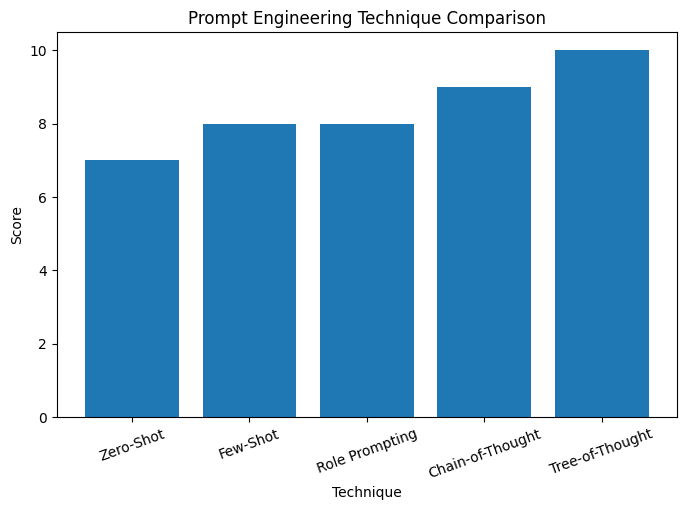

In [22]:
import matplotlib.pyplot as plt

techniques = [
    "Zero-Shot",
    "Few-Shot",
    "Role Prompting",
    "Chain-of-Thought",
    "Tree-of-Thought"
]

scores = [7, 8, 8, 9, 10]

plt.figure(figsize=(8,5))
plt.bar(techniques, scores)

plt.title("Prompt Engineering Technique Comparison")
plt.xlabel("Technique")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.show()